In [1]:

# Install Packages


!pip uninstall -y transformers tokenizers huggingface-hub accelerate -q

!pip install -q --no-cache-dir -U \
    "transformers>=5.0,<6.0" \
    "huggingface-hub>=1.16,<2.0" \
    "accelerate>=1.0" \
    "sentencepiece==0.2.2" \
    "protobuf==5.29.6" \
    opencv-python-headless \
    pillow \
    matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 205.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 793.2/793.2 kB 273.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 277.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 108.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 118.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 259.9 MB/s eta 0:00:00


In [2]:
import transformers
import tokenizers
import huggingface_hub
import accelerate
import sentencepiece
import google.protobuf
import torch

print("Transformers :", transformers.__version__)
print("Tokenizers   :", tokenizers.__version__)
print("HF Hub       :", huggingface_hub.__version__)
print("Accelerate   :", accelerate.__version__)
print("SentencePiece:", sentencepiece.__version__)
print("Protobuf     :", google.protobuf.__version__)
print("PyTorch      :", torch.__version__)
print("CUDA         :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Transformers : 5.16.1
Tokenizers   : 0.23.1
HF Hub       : 1.28.0
Accelerate   : 1.14.0
SentencePiece: 0.2.2
Protobuf     : 5.29.6
PyTorch      : 2.11.0+cu128
CUDA         : True
GPU: Tesla T4


In [3]:
!pip uninstall -y pillow -q
!pip install --no-cache-dir --force-reinstall "pillow>=11.0,<12.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 56.1 MB/s eta 0:00:00


In [4]:
from PIL import Image
import PIL

print("Pillow:", PIL.__version__)
print("Pillow path:", PIL.__file__)
print("PIL import: OK")

Pillow: 11.3.0
Pillow path: /usr/local/lib/python3.13/dist-packages/PIL/__init__.py
PIL import: OK


In [5]:
import transformers

print("Transformers:", transformers.__version__)

from transformers import (
    ViTImageProcessor,
    RobertaTokenizer,
    VisionEncoderDecoderModel,
)

print("✓ Transformers imports successfully")

Transformers: 5.16.1
✓ Transformers imports successfully


In [6]:
import json
import os

import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt

from PIL import Image
from IPython.display import display

from transformers import (
    ViTImageProcessor,
    RobertaTokenizer,
    VisionEncoderDecoderModel,
)

MODEL_NAME = "microsoft/trocr-base-handwritten"

MAX_IMAGE_WIDTH = 1800
LINE_PADDING = 15
MAX_NEW_TOKENS = 128
NUM_BEAMS = 4

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("             OCR CONFIGURATION")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "VRAM:",
        round(
            torch.cuda.get_device_properties(0).total_memory
            / 1024**3,
            2
        ),
        "GB"
    )
else:
    print("WARNING: CUDA GPU not detected.")

             OCR CONFIGURATION
Device: cuda
GPU: Tesla T4
VRAM: 14.56 GB


In [7]:

# Imports and Configuration


import json
import os

import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt

from PIL import Image
from IPython.display import display

from transformers import (
    ViTImageProcessor,
    RobertaTokenizer,
    VisionEncoderDecoderModel,
)


# Configuration


MODEL_NAME = "microsoft/trocr-base-handwritten"
MAX_IMAGE_WIDTH = 1800
LINE_PADDING = 15
MAX_NEW_TOKENS = 128
NUM_BEAMS = 4


# Device


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("OCR CONFIGURATION")
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "VRAM:",
        round(
            torch.cuda.get_device_properties(0).total_memory
            / 1024**3,
            2
        ),
        "GB"
    )
else:
    print("WARNING: CUDA GPU not detected.")

             OCR CONFIGURATION
Device: cuda
GPU: Tesla T4
VRAM: 14.56 GB


In [9]:

# Load TrOCR


print()
print("LOADING TrOCR")

print("Loading image processor...")

image_processor = ViTImageProcessor.from_pretrained(
    MODEL_NAME
)

print("✓ Image processor loaded")


print("Loading tokenizer...")

tokenizer = RobertaTokenizer.from_pretrained(
    MODEL_NAME,
    use_fast=False
)

print("✓ Tokenizer loaded")


print("Loading model...")

model = VisionEncoderDecoderModel.from_pretrained(
    MODEL_NAME
)

model = model.to(device)

# FP16 for NVIDIA T4
if device.type == "cuda":
    model = model.half()

model.eval()

print("✓ Model loaded")
print()
print("TrOCR READY")


LOADING TrOCR
Loading image processor...
✓ Image processor loaded
Loading tokenizer...
✓ Tokenizer loaded
Loading model...


Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Model loaded

TrOCR READY


In [53]:

# Upload Prescription Images


from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
import os


class PrescriptionDataset(Dataset):

    def __init__(self, csv_file, image_dir, transform=None):

        self.data = pd.read_csv(csv_file)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):

        row = self.data.iloc[index]

        image_path = os.path.join(
            self.image_dir,
            row["image"]
        )

        image = Image.open(image_path).convert("RGB")

        text = row["text"]

        if self.transform:
            image = self.transform(image)

        return {
            "image": image,
            "text": text,
            "image_path": image_path
        }

In [54]:
import os
import shutil

os.makedirs("/content/images", exist_ok=True)

image_files = [
    "images-3.jpeg",
    "images-2.jpeg",
    "Image-1.jpg",
    "Image-4.webp"
]

for file in image_files:
    source = f"/content/{file}"
    destination = f"/content/images/{file}"

    if os.path.exists(source):
        shutil.copy(source, destination)

print(os.listdir("/content/images"))

['images-3.jpeg', 'images-2.jpeg']


In [89]:
# Image parsing

import pandas as pd

data = {
    "image": [
        "images-3.jpeg",
        "images-2.jpeg",
        "Image-1.webp",
        "Image-4.jpg"
    ],
    "text": [
        "PUT TRANSCRIPTION FOR IMAGE 1 HERE",
        "PUT TRANSCRIPTION FOR IMAGE 2 HERE",
        "PUT TRANSCRIPTION FOR IMAGE 3 HERE",
        "PUT TRANSCRIPTION FOR IMAGE 4 HERE"
    ]
}

df = pd.DataFrame(data)

df.to_csv(
    "/content/prescriptions.csv",
    index=False
)

print(df)

           image                                text
0  images-3.jpeg  PUT TRANSCRIPTION FOR IMAGE 1 HERE
1  images-2.jpeg  PUT TRANSCRIPTION FOR IMAGE 2 HERE
2   Image-1.webp  PUT TRANSCRIPTION FOR IMAGE 3 HERE
3    Image-4.jpg  PUT TRANSCRIPTION FOR IMAGE 4 HERE


In [56]:
# Training and Testing

from sklearn.model_selection import train_test_split

data = pd.read_csv("/content/prescriptions.csv")

train_data, temp_data = train_test_split(
    data,
    test_size=0.30,
    random_state=42
)

validation_data, test_data = train_test_split(
    temp_data,
    test_size=0.50,
    random_state=42
)

train_data.to_csv(
    "/content/train.csv",
    index=False
)

validation_data.to_csv(
    "/content/validation.csv",
    index=False
)

test_data.to_csv(
    "/content/test.csv",
    index=False
)

print("Train:", len(train_data))
print("Validation:", len(validation_data))
print("Test:", len(test_data))

Train: 2
Validation: 1
Test: 1


In [57]:
# Train Dataset

train_dataset = PrescriptionDataset(
    "/content/train.csv",
    "/content/images"
)

validation_dataset = PrescriptionDataset(
    "/content/validation.csv",
    "/content/images"
)

test_dataset = PrescriptionDataset(
    "/content/test.csv",
    "/content/images"
)

In [58]:
# Import DataLoader

from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=4,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False
)

In [59]:
# Display Directory

import os

print("Current directory:")
print(os.getcwd())

print("\nFiles and folders:")
print(os.listdir())



Current directory:
/content

Files and folders:
['.config', 'validation.csv', 'Image-4.jpg', 'prescriptions.csv', 'test.csv', 'images-3.jpeg', 'images-2.jpeg', 'Image-5.jpg.webp', '.ipynb_checkpoints', 'images', 'Image-1.webp', 'train.csv']


In [60]:
train_dataset = PrescriptionDataset(
    "train.csv",
    "images"
)

In [61]:
# Display Contents of Directory

import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

/content/validation.csv
/content/prescriptions.csv
/content/test.csv
/content/train.csv


In [62]:
# Training Data Loader

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=4,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False
)

In [63]:
# OCR Images

def perform_ocr(image):
    ...

def extract_medications(text):
    ...

def extract_diagnosis(text):
    ...

def extract_patient_information(text):
    ...

def extract_allergies(text):
    ...

def extract_follow_up(text):
    ...

def build_prescription(text):
    ...

Image loaded:
Path: /content/Image-1.webp
Size: (720, 939)


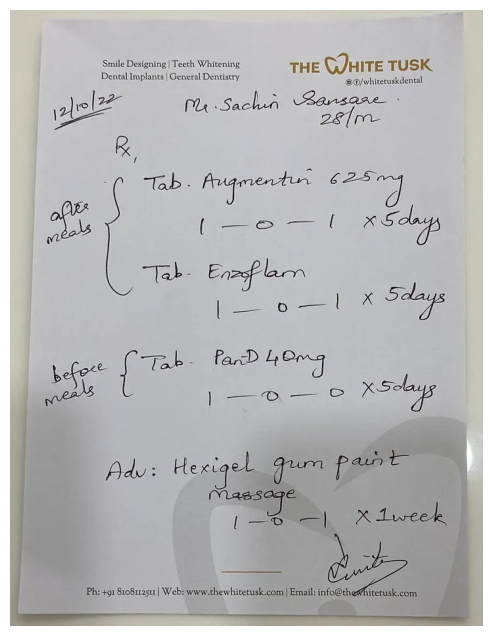

In [65]:
from PIL import Image
import os
import matplotlib.pyplot as plt

image_path = "/content/Image-1.webp"

if not os.path.exists(image_path):
    raise FileNotFoundError(
        f"Image not found: {image_path}"
    )

image = Image.open(image_path).convert("RGB")

print("Image loaded:")
print("Path:", image_path)
print("Size:", image.size)

plt.figure(figsize=(12, 8))
plt.imshow(image)
plt.axis("off")
plt.show()

In [66]:
# Transcription

transcription = perform_ocr(image)

prescription = build_prescription(
    transcription
)

In [67]:
# Training and Testing Validation

from sklearn.model_selection import train_test_split

data = pd.read_csv("prescriptions.csv")

train, temp = train_test_split(
    data,
    test_size=0.30,
    random_state=42
)

validation, test = train_test_split(
    temp,
    test_size=0.50,
    random_state=42
)

train.to_csv("train.csv", index=False)
validation.to_csv("validation.csv", index=False)
test.to_csv("test.csv", index=False)

In [74]:
# Preprocessing of Image

def preprocess_image(
    pil_image,
    max_width=MAX_IMAGE_WIDTH
):

    return pil_image

In [75]:
class PrescriptionDataset(Dataset):

    def __getitem__(self, index):

        row = self.data.iloc[index]

        image_path = os.path.join(
            self.image_dir,
            row["image"]
        )

        image = Image.open(
            image_path
        ).convert("RGB")

        original, processed = preprocess_image(
            image
        )

        return {
            "image": processed,
            "text": row["text"]
        }

In [77]:
def preprocess_image(row):
    image = row["image"]

    processed = preprocess_image(
        image,
        max_width=MAX_IMAGE_WIDTH
    )

    return {
        "original_image": image,
        "processed_image": processed,
        "text": row["text"]
    }

Processed image shape: (939, 720, 3)


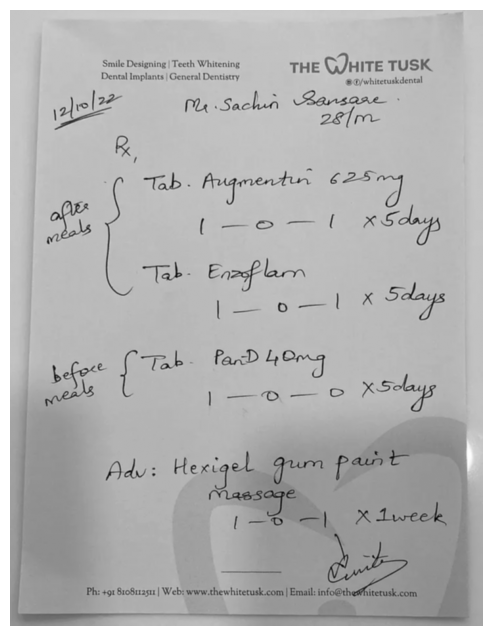

In [78]:

#  Image Preprocssing


def preprocess_image(pil_image, max_width=MAX_IMAGE_WIDTH):

    image = np.array(pil_image)

    # RGB → BGR
    image = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2BGR
    )

    # Resize large images
    height, width = image.shape[:2]

    if width > max_width:

        scale = max_width / width

        image = cv2.resize(
            image,
            None,
            fx=scale,
            fy=scale,
            interpolation=cv2.INTER_AREA
        )

    # Grayscale
    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    # Contrast normalization
    gray = cv2.normalize(
        gray,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    )

    # Light denoising
    gray = cv2.GaussianBlur(
        gray,
        (3, 3),
        0
    )

    return image, gray


original, gray = preprocess_image(image)

print("Processed image shape:", original.shape)

plt.figure(figsize=(12, 8))
plt.imshow(gray, cmap="gray")
plt.axis("off")
plt.show()

In [80]:
# Detect Text Lines


def detect_text_lines(gray):

    binary = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )[1]

    kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (35, 3)
    )

    connected = cv2.morphologyEx(
        binary,
        cv2.MORPH_CLOSE,
        kernel
    )

    contours, _ = cv2.findContours(
        connected,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    height, width = gray.shape

    boxes = []

    for contour in contours:

        x, y, w, h = cv2.boundingRect(contour)

        if w < 40:
            continue

        if h < 8:
            continue

        if w * h < 500:
            continue

        if w > width * 0.95:
            continue

        boxes.append(
            (x, y, w, h)
        )

    # Top → bottom
    boxes.sort(
        key=lambda box: box[1]
    )

    return boxes


boxes = detect_text_lines(gray)

print("Detected regions:", len(boxes))

Detected regions: 12


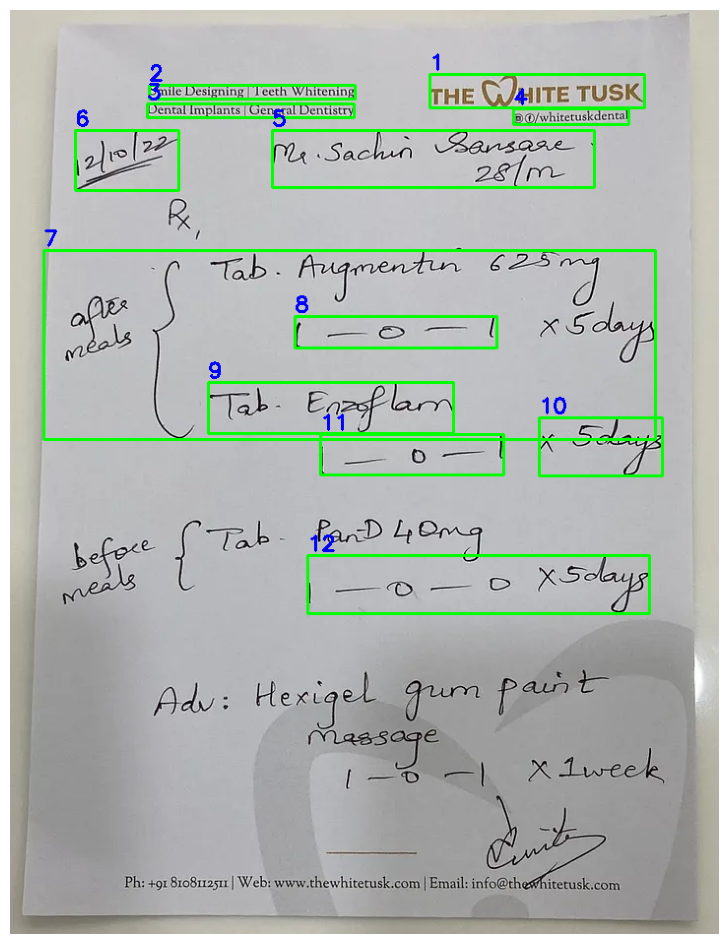

In [82]:
# Visualize Detected Lines


display_image = original.copy()

for index, (x, y, w, h) in enumerate(boxes):

    cv2.rectangle(
        display_image,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        2
    )

    cv2.putText(
        display_image,
        str(index + 1),
        (x, max(20, y - 5)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 0, 0),
        2
    )


plt.figure(figsize=(15, 12))

plt.imshow(
    cv2.cvtColor(
        display_image,
        cv2.COLOR_BGR2RGB
    )
)

plt.axis("off")
plt.show()

In [83]:
# OCR Function


@torch.inference_mode()
def recognize_line(crop):

    # OpenCV BGR → PIL RGB
    crop = cv2.cvtColor(
        crop,
        cv2.COLOR_BGR2RGB
    )

    crop = Image.fromarray(crop).convert("RGB")

    # Image → tensor
    pixel_values = image_processor(
        images=crop,
        return_tensors="pt"
    ).pixel_values

    pixel_values = pixel_values.to(device)

    if device.type == "cuda":
        pixel_values = pixel_values.half()

    # Generate OCR tokens
    generated_ids = model.generate(
        pixel_values,
        max_new_tokens=MAX_NEW_TOKENS,
        num_beams=NUM_BEAMS
    )

    # Tokens → text
    text = tokenizer.batch_decode(
        generated_ids,
        skip_special_tokens=True
    )[0]

    return text.strip()

In [84]:
# Run Handwriting OCR


ocr_results = []

for index, (x, y, w, h) in enumerate(boxes):

    x1 = max(
        0,
        x - LINE_PADDING
    )

    y1 = max(
        0,
        y - LINE_PADDING
    )

    x2 = min(
        original.shape[1],
        x + w + LINE_PADDING
    )

    y2 = min(
        original.shape[0],
        y + h + LINE_PADDING
    )

    crop = original[
        y1:y2,
        x1:x2
    ]

    text = recognize_line(crop)

    result = {
        "line": index + 1,
        "bbox": [
            x1,
            y1,
            x2,
            y2
        ],
        "text": text
    }

    ocr_results.append(result)

    print(
        f"Line {index + 1}: {text}"
    )

Line 1: the Whitetusk
Line 2: Smile Designing . Tooth . Whitening
Line 3: Bonnington Elementary .
Line 4: administributional
Line 5: Mr. Sachin Banzzaze .
Line 6: 12liolyz
Line 7: " Francis E. Tate , Thompson , is a colleague
Line 8: 1-0021
Line 9: Tab. Enzoflorn
Line 10: x 50days .
Line 11: 1-pool .
Line 12: " to-to Sundays .


In [85]:
#  Combine Transcription


transcription = "\n".join(
    item["text"]
    for item in ocr_results
    if item["text"]
)

print()
print("DIGITAL TRANSCRIPTION")
print(transcription)


DIGITAL TRANSCRIPTION
the Whitetusk
Smile Designing . Tooth . Whitening
Bonnington Elementary .
administributional
Mr. Sachin Banzzaze .
12liolyz
" Francis E. Tate , Thompson , is a colleague
1-0021
Tab. Enzoflorn
x 50days .
1-pool .
" to-to Sundays .


In [86]:
#  Creation of Clinical Digital Document


def create_medical_draft(transcription):

    draft = {
        "patient_name": None,
        "diagnosis": [],
        "symptoms": [],
        "medications": [],
        "allergies": [],
        "assessment": None,
        "plan": None,
        "follow_up": None,
        "uncertain_items": []
    }

    lines = [
        line.strip()
        for line in transcription.splitlines()
        if line.strip()
    ]

    medication_words = {
        "mg",
        "mcg",
        "tablet",
        "tab",
        "capsule",
        "cap",
        "ml"
    }

    for line in lines:

        lower = line.lower()

        # Follow-up
        if any(
            term in lower
            for term in (
                "follow up",
                "follow-up",
                "return"
            )
        ):
            draft["follow_up"] = line
            continue

        # Allergies
        if "allerg" in lower:
            draft["allergies"].append(line)
            continue

        # Medication heuristic
        if any(
            word in lower
            for word in medication_words
        ):
            draft["medications"].append({
                "source_text": line,
                "name": None,
                "dose": None,
                "route": None,
                "frequency": None,
                "duration": None,
                "instructions": None,
                "confidence": 0.0
            })
            continue

        # Everything else requires review
        draft["uncertain_items"].append(line)

    return draft


draft = create_medical_draft(
    transcription
)

print(
    json.dumps(
        draft,
        indent=2
    )
)

{
  "patient_name": null,
  "diagnosis": [],
  "symptoms": [],
  "medications": [
    {
      "source_text": "Tab. Enzoflorn",
      "name": null,
      "dose": null,
      "route": null,
      "frequency": null,
      "duration": null,
      "instructions": null,
      "confidence": 0.0
    }
  ],
  "allergies": [],
  "assessment": null,
  "plan": null,
  "follow_up": null,
  "uncertain_items": [
    "the Whitetusk",
    "Smile Designing . Tooth . Whitening",
    "Bonnington Elementary .",
    "administributional",
    "Mr. Sachin Banzzaze .",
    "12liolyz",
    "\" Francis E. Tate , Thompson , is a colleague",
    "1-0021",
    "x 50days .",
    "1-pool .",
    "\" to-to Sundays ."
  ]
}


In [87]:
# Display Clinical Digital Document


print()
print("       AI CLINICAL DOCUMENT DRAFT")


print()
print("STATUS: REQUIRES PHYSICIAN REVIEW")

print()
print("RAW TRANSCRIPTION")
print("-" * 40)

for item in ocr_results:

    print(
        f"[{item['line']}] {item['text']}"
    )


print()
print("MEDICATIONS")
print("-" * 40)

if draft["medications"]:

    for medication in draft["medications"]:

        print(
            "Source:",
            medication["source_text"]
        )

        print(
            "⚠ Medication fields require verification."
        )

else:

    print("No medication lines identified.")


print()
print("UNCERTAIN ITEMS")
print("-" * 40)

if draft["uncertain_items"]:

    for item in draft["uncertain_items"]:
        print("⚠", item)

else:

    print("None")


       AI CLINICAL DOCUMENT DRAFT

STATUS: REQUIRES PHYSICIAN REVIEW

RAW TRANSCRIPTION
----------------------------------------
[1] the Whitetusk
[2] Smile Designing . Tooth . Whitening
[3] Bonnington Elementary .
[4] administributional
[5] Mr. Sachin Banzzaze .
[6] 12liolyz
[7] " Francis E. Tate , Thompson , is a colleague
[8] 1-0021
[9] Tab. Enzoflorn
[10] x 50days .
[11] 1-pool .
[12] " to-to Sundays .

MEDICATIONS
----------------------------------------
Source: Tab. Enzoflorn
⚠ Medication fields require verification.

UNCERTAIN ITEMS
----------------------------------------
⚠ the Whitetusk
⚠ Smile Designing . Tooth . Whitening
⚠ Bonnington Elementary .
⚠ administributional
⚠ Mr. Sachin Banzzaze .
⚠ 12liolyz
⚠ " Francis E. Tate , Thompson , is a colleague
⚠ 1-0021
⚠ x 50days .
⚠ 1-pool .
⚠ " to-to Sundays .


In [88]:
# Save Digital Document


output = {
    "status": "DRAFT_REQUIRES_PHYSICIAN_REVIEW",
    "ocr_lines": ocr_results,
    "transcription": transcription,
    "clinical_draft": draft
}

output_file = "medical_document_draft.json"

with open(
    output_file,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        output,
        f,
        indent=2,
        ensure_ascii=False
    )

print(f"Saved: {output_file}")

Saved: medical_document_draft.json


In [ ]:
# GPU Memory


if torch.cuda.is_available():

    allocated = (
        torch.cuda.memory_allocated()
        / 1024**3
    )

    reserved = (
        torch.cuda.memory_reserved()
        / 1024**3
    )

    print("GPU Memory")
    print("----------")
    print(f"Allocated: {allocated:.2f} GB")
    print(f"Reserved:  {reserved:.2f} GB")

GPU Memory
----------
Allocated: 0.66 GB
Reserved:  1.42 GB
